In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [5]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [9]:
df = pd.read_csv("USA_Housing.csv")

print(f"Dimensions du dataset : {df.shape}")
print(f"\nNombre d'observations : {df.shape[0]}")
print(f"Nombre de variables : {df.shape[1]}")
df.head()

Dimensions du dataset : (5000, 7)

Nombre d'observations : 5000
Nombre de variables : 7


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [11]:
print("Aperçu des données :")
print(df.head(10))

print("\n" + "="*80)
print("Informations sur les colonnes :")
print(df.info())

Aperçu des données :
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   
5      80175.754159             4.988408                   6.104512   
6      64698.463428             6.025336                   8.147760   
7      78394.339278             6.989780                   6.620478   
8      59927.660813             5.362126                   6.393121   
9      81885.927184             4.423672                   8.167688   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   

In [13]:
print("Statistiques descriptives :")
print(df.describe().round(2))

Statistiques descriptives :
       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
count           5000.00              5000.00                    5000.00   
mean           68583.11                 5.98                       6.99   
std            10657.99                 0.99                       1.01   
min            17796.63                 2.64                       3.24   
25%            61480.56                 5.32                       6.30   
50%            68804.29                 5.97                       7.00   
75%            75783.34                 6.65                       7.67   
max           107701.75                 9.52                      10.76   

       Avg. Area Number of Bedrooms  Area Population       Price  
count                       5000.00          5000.00     5000.00  
mean                           3.98         36163.52  1232072.65  
std                            1.23          9925.65   353117.63  
min                         

In [16]:
valeurs_manquantes = df.isnull().sum()
pourcentage_manquant = (valeurs_manquantes / len(df)) * 100

rapport_qualite = pd.DataFrame({
    'Valeurs_Manquantes': valeurs_manquantes,
    'Pourcentage': pourcentage_manquant
})

print("Rapport de qualité des données :")
print(rapport_qualite[rapport_qualite['Valeurs_Manquantes'] > 0])

if rapport_qualite['Valeurs_Manquantes'].sum() == 0:
    print("\n✓ Aucune valeur manquante détectée")

Rapport de qualité des données :
Empty DataFrame
Columns: [Valeurs_Manquantes, Pourcentage]
Index: []

✓ Aucune valeur manquante détectée


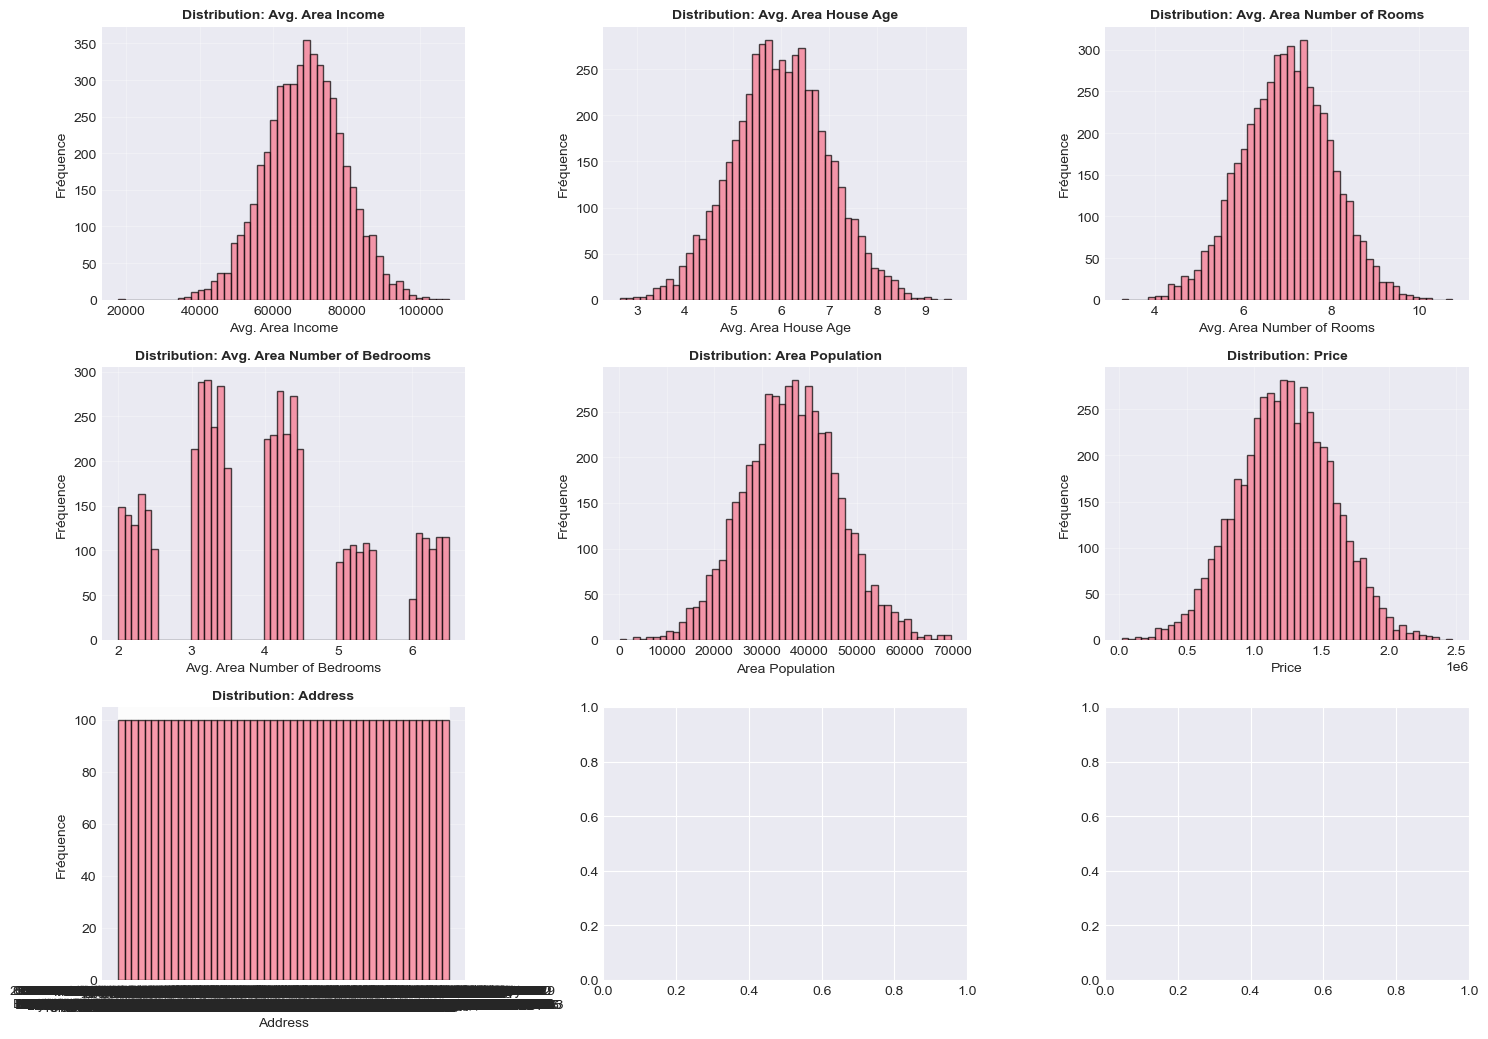

In [31]:
import numpy as np
import matplotlib.pyplot as plt

cols = 3
n = len(df.columns)
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3.5*rows))
axes = np.array(axes).ravel()

for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution: {col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Fréquence')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

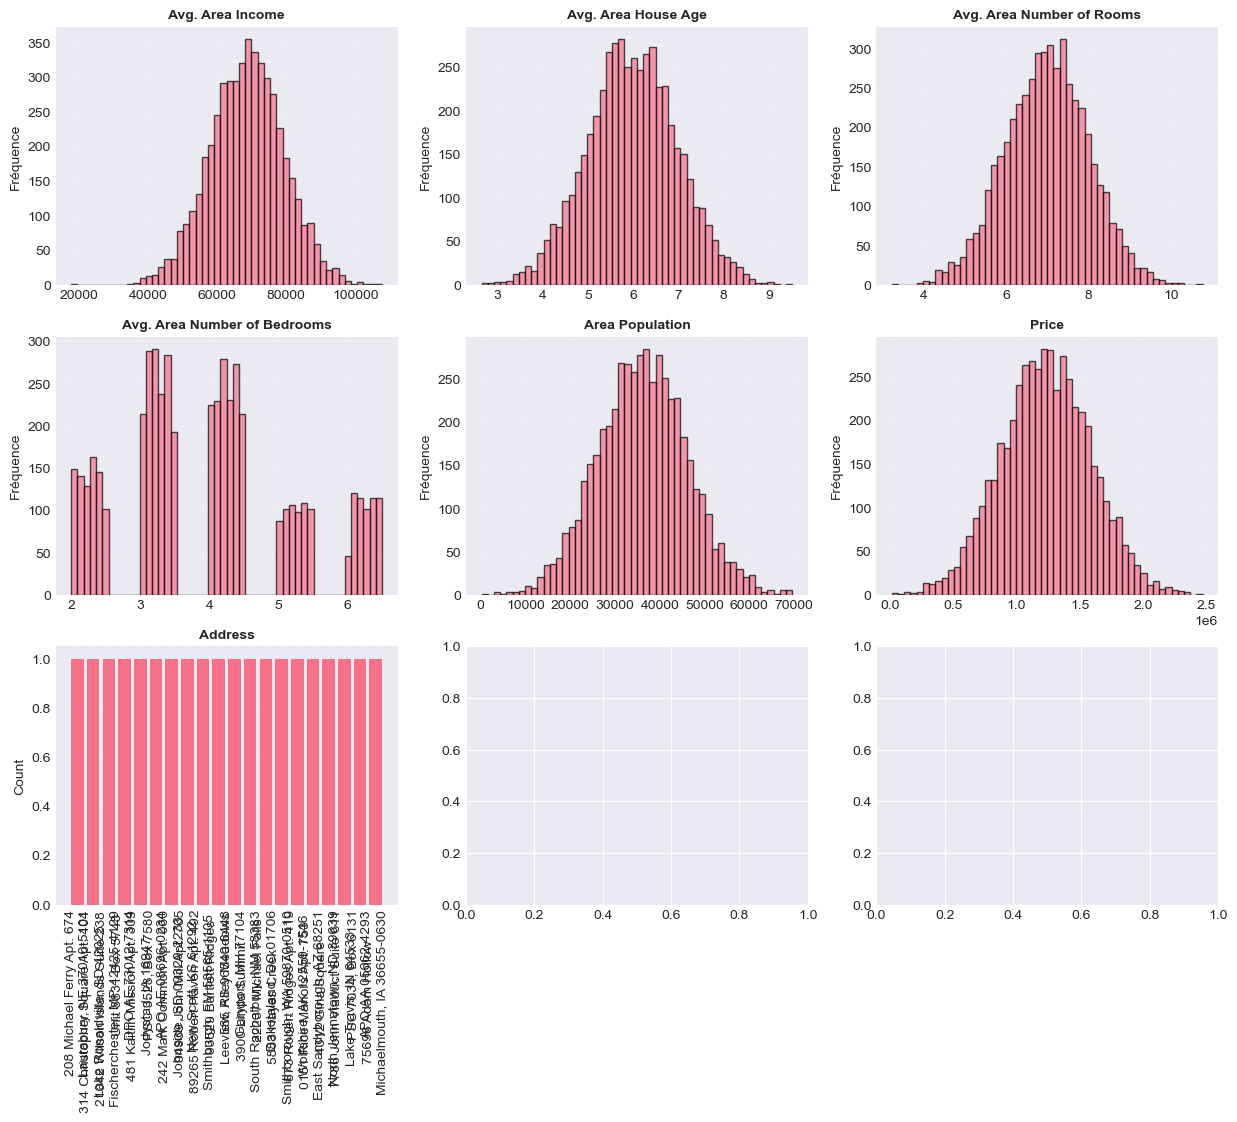

In [33]:
import numpy as np
import matplotlib.pyplot as plt

cols = 3
n = len(df.columns)
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3.8*rows))
axes = np.array(axes).ravel()

for idx, col in enumerate(df.columns):
    s = df[col].dropna()

    if s.shape[0] == 0:
        axes[idx].text(0.5, 0.5, f"{col}\n(كلو NaN)", ha="center", va="center")
        axes[idx].set_axis_off()
        continue

    # إذا كان رقمي
    if np.issubdtype(s.dtype, np.number):
        axes[idx].hist(s, bins=50, edgecolor="black", alpha=0.7)
        axes[idx].set_ylabel("Fréquence")
    else:
        # إذا كان نصّي/فئات
        top = s.astype(str).value_counts().head(20)
        axes[idx].bar(top.index, top.values)
        axes[idx].tick_params(axis="x", rotation=90)
        axes[idx].set_ylabel("Count")

    axes[idx].set_title(f"{col}", fontsize=10, fontweight="bold")
    axes[idx].grid(True, alpha=0.2)

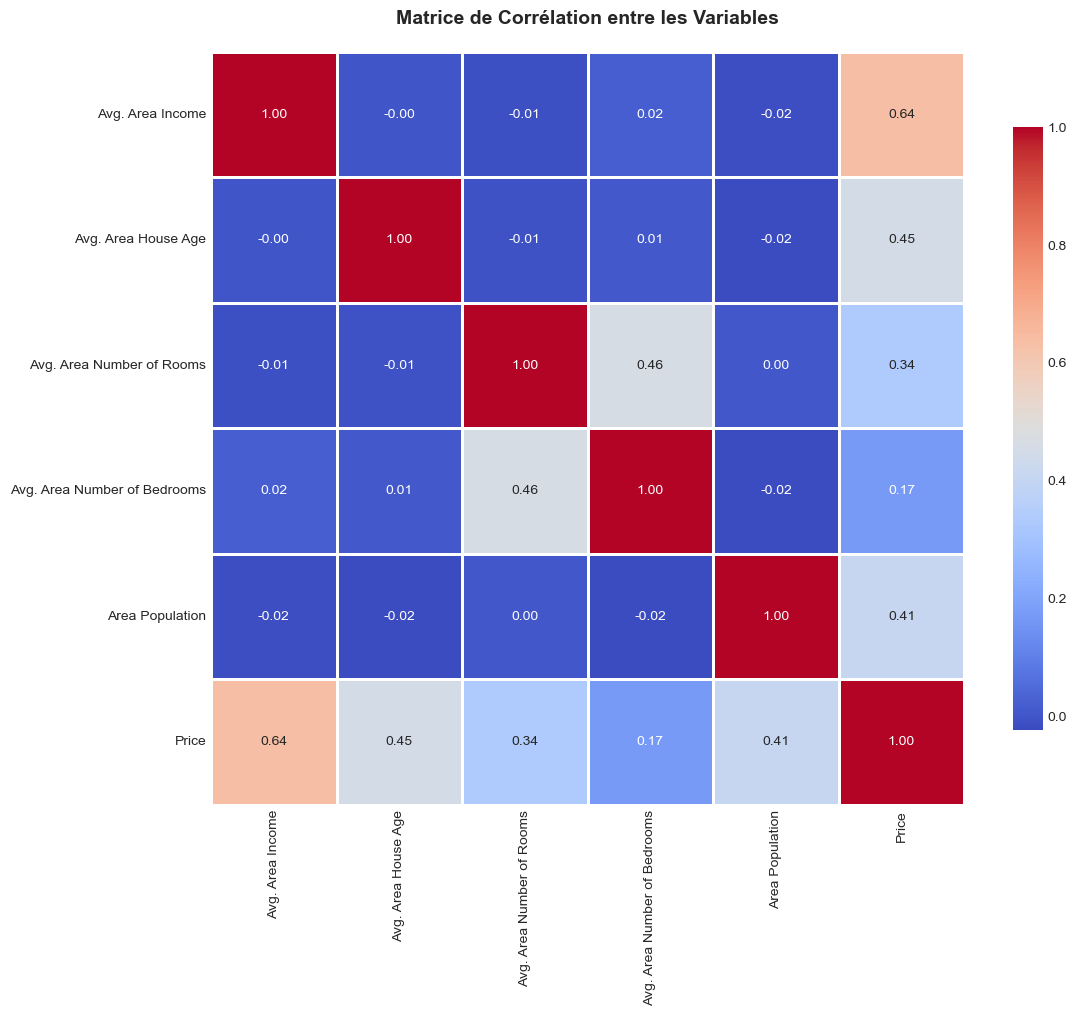

In [36]:
df_num = df.select_dtypes(include="number")

matrice_correlation = df_num.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    matrice_correlation,
    annot=True, fmt=".2f", cmap="coolwarm",
    square=True, linewidths=1, cbar_kws={"shrink": 0.8}
)
plt.title("Matrice de Corrélation entre les Variables", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

In [40]:
candidates = ["Price", "price", "PRICE", "SalePrice", "target"]
target_col = next((c for c in candidates if c in matrice_correlation.columns), None)

if target_col is None:
    target_col = matrice_correlation.columns[-1]

print("Target detected:", target_col)

print(f"\nCorrélations avec {target_col} (Variable Cible) :")
print(matrice_correlation[target_col].sort_values(ascending=False))

Target detected: Price

Corrélations avec Price (Variable Cible) :
Price                           1.000000
Avg. Area Income                0.639734
Avg. Area House Age             0.452543
Area Population                 0.408556
Avg. Area Number of Rooms       0.335664
Avg. Area Number of Bedrooms    0.171071
Name: Price, dtype: float64


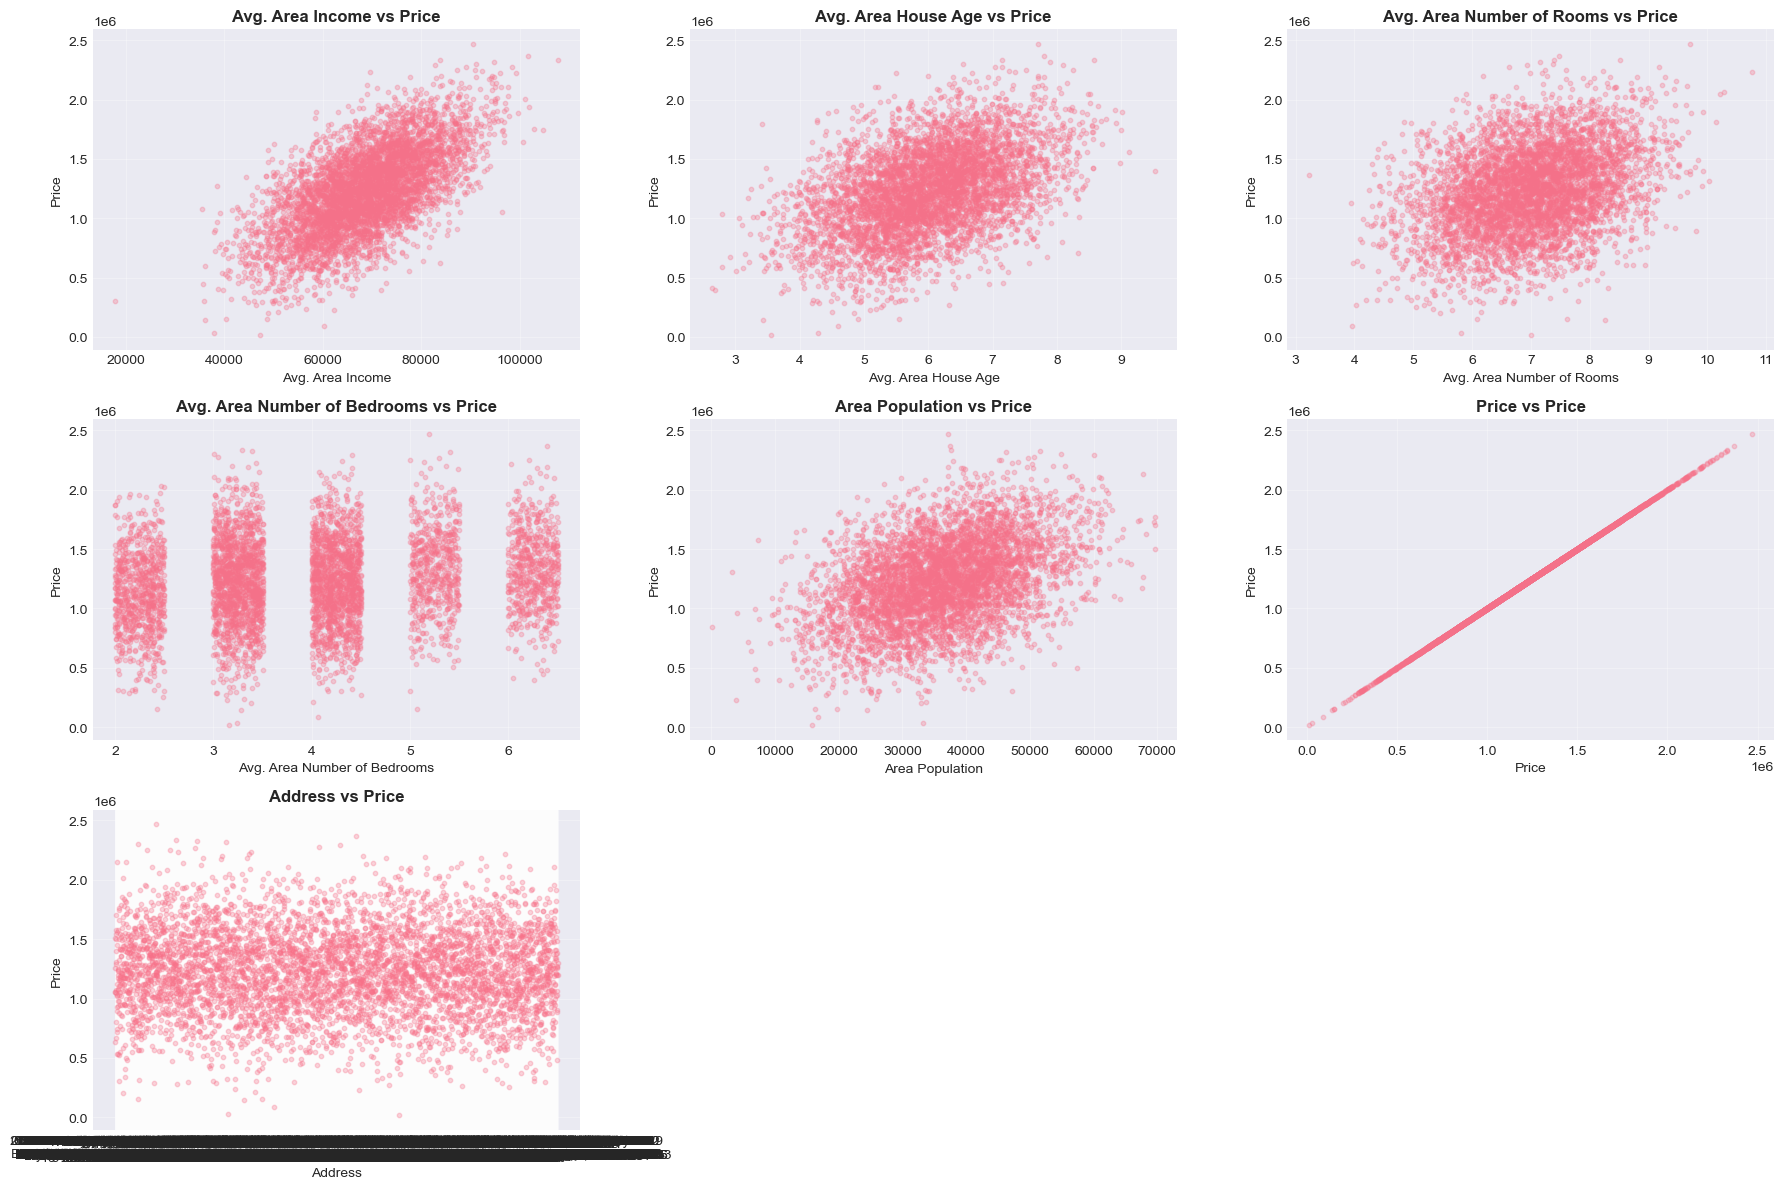

In [46]:
ariables_explicatives = [col for col in df.columns if col not in ['Price', 'Address']]

cols = 3
rows = int(np.ceil(len(variables_explicatives)/cols))
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = np.array(axes).ravel()

for idx, col in enumerate(variables_explicatives):
    axes[idx].scatter(df[col], df['Price'], alpha=0.3, s=10)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Price')
    axes[idx].set_title(f'{col} vs Price', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

for j in range(idx+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [48]:
df_engineered = df.copy()

if "Address" in df_engineered.columns:
    df_engineered.drop(columns=["Address"], inplace=True)

if ("Avg. Area Number of Rooms" in df_engineered.columns) and ("Avg. Area Number of Bedrooms" in df_engineered.columns):
    df_engineered["RoomsPerBedroom"] = df_engineered["Avg. Area Number of Rooms"] / df_engineered["Avg. Area Number of Bedrooms"]

if ("Area Population" in df_engineered.columns) and ("Avg. Area Number of Rooms" in df_engineered.columns):
    df_engineered["PopulationPerRoom"] = df_engineered["Area Population"] / df_engineered["Avg. Area Number of Rooms"]

if ("Avg. Area Number of Bedrooms" in df_engineered.columns) and ("Avg. Area Number of Rooms" in df_engineered.columns):
    df_engineered["BedroomRatio"] = df_engineered["Avg. Area Number of Bedrooms"] / df_engineered["Avg. Area Number of Rooms"]

if ("Avg. Area Income" in df_engineered.columns) and ("Area Population" in df_engineered.columns):
    df_engineered["IncomePerPopProxy"] = df_engineered["Avg. Area Income"] / df_engineered["Area Population"]

df_engineered.replace([np.inf, -np.inf], np.nan, inplace=True)
df_engineered.dropna(inplace=True)

print("Shape after FE:", df_engineered.shape)
new_feats = [c for c in ["RoomsPerBedroom","PopulationPerRoom","BedroomRatio","IncomePerPopProxy"] if c in df_engineered.columns]
print("New features:", new_feats)
display(df_engineered.head())

Shape after FE: (5000, 10)
New features: ['RoomsPerBedroom', 'PopulationPerRoom', 'BedroomRatio', 'IncomePerPopProxy']


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,RoomsPerBedroom,PopulationPerRoom,BedroomRatio,IncomePerPopProxy
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,1.713738,3293.790954,0.583520,3.445495
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,2.178259,5968.524800,0.459082,1.972681
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,1.659401,4332.590195,0.602627,1.661700
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,1.713720,6141.383427,0.583526,1.846249
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,1.853283,3361.756070,0.539583,2.276009


In [52]:
target_candidates = ["Price", "price", "MEDV", "target"]
target = next((c for c in target_candidates if c in df.columns), None)

if target is None:
    raise ValueError(f"ما لقيتش target معروف. الأعمدة اللي عندك: {list(df.columns)}")

X = df.drop(columns=[target])
y = df[target]

obj_cols = X.select_dtypes(include=["object"]).columns
print("Object columns:", list(obj_cols))
X = X.drop(columns=obj_cols)

Object columns: ['Address']


In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement : {X_train.shape}")
print(f"Taille de l'ensemble de test : {X_test.shape}")
print(f"\nProportion train/test : {len(X_train)/len(X) * 100:.1f}% / {len(X_test)/len(X) * 100:.1f}%")

Taille de l'ensemble d'entraînement : (4000, 5)
Taille de l'ensemble de test : (1000, 5)

Proportion train/test : 80.0% / 20.0%


In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Standardisation effectuée avec succès")
print(f"\nMoyenne des features après standardisation (train) :")
print(np.round(X_train_scaled.mean(axis=0), 4))
print(f"\nÉcart-type des features après standardisation (train) :")
print(np.round(X_train_scaled.std(axis=0), 4))

Standardisation effectuée avec succès

Moyenne des features après standardisation (train) :
[-0. -0. -0. -0.  0.]

Écart-type des features après standardisation (train) :
[1. 1. 1. 1. 1.]


In [59]:
modeles = {
    'Régression Linéaire': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Arbre de Décision': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Support Vector Machine': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}
resultats = {}
for nom, modele in modeles.items():
    print(f"\nEntraînement : {nom}...")

modele.fit(X_train_scaled, y_train)


Entraînement : Régression Linéaire...

Entraînement : Ridge Regression...

Entraînement : Lasso Regression...

Entraînement : Arbre de Décision...

Entraînement : Random Forest...

Entraînement : Support Vector Machine...


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [63]:
modeles = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "SVR": SVR(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42, n_estimators=300),
}

resultats = {}

for nom, modele in modeles.items():
    print(f"\nEntraînement de: {nom}")

    # موديلات كتحتاج scaling
    if nom in ["LinearRegression", "Ridge", "Lasso", "SVR"]:
        modele.fit(X_train_scaled, y_train)
        y_pred_train = modele.predict(X_train_scaled)
        y_pred_test  = modele.predict(X_test_scaled)
    else:
        modele.fit(X_train, y_train)
        y_pred_train = modele.predict(X_train)
        y_pred_test  = modele.predict(X_test)

    resultats[nom] = {
        "modele": modele,
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_test": r2_score(y_test, y_pred_test),
        "rmse_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "rmse_test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "mae_train": mean_absolute_error(y_train, y_pred_train),
        "mae_test": mean_absolute_error(y_test, y_pred_test),
        "predictions": y_pred_test
    }

    print("  ✓ Entraînement terminé")


Entraînement de: LinearRegression
  ✓ Entraînement terminé

Entraînement de: Ridge
  ✓ Entraînement terminé

Entraînement de: Lasso
  ✓ Entraînement terminé

Entraînement de: SVR
  ✓ Entraînement terminé

Entraînement de: DecisionTree
  ✓ Entraînement terminé

Entraînement de: RandomForest
  ✓ Entraînement terminé


In [64]:
comparaison = pd.DataFrame({
    'Modèle': list(resultats.keys()),
    'R² Train': [resultats[m]['r2_train'] for m in resultats],
    'R² Test': [resultats[m]['r2_test'] for m in resultats],
    'RMSE Train': [resultats[m]['rmse_train'] for m in resultats],
    'RMSE Test': [resultats[m]['rmse_test'] for m in resultats],
    'MAE Train': [resultats[m]['mae_train'] for m in resultats],
    'MAE Test': [resultats[m]['mae_test'] for m in resultats]
})

In [65]:
comparaison = comparaison.sort_values('R² Test', ascending=False)

print("\n" + "="*100)
print("TABLEAU COMPARATIF DES PERFORMANCES")
print("="*100)
print(comparaison.to_string(index=False))
print("="*100)


TABLEAU COMPARATIF DES PERFORMANCES
          Modèle  R² Train   R² Test    RMSE Train     RMSE Test     MAE Train      MAE Test
           Ridge  0.917979  0.917997 101273.524551 100444.030130  81511.225110  80877.763040
           Lasso  0.917979  0.917997 101273.485511 100444.060047  81509.393394  80879.096765
LinearRegression  0.917979  0.917997 101273.485511 100444.060556  81509.393312  80879.097235
    RandomForest  0.984312  0.883440  44291.217466 119752.414804  35223.536157  94047.776385
    DecisionTree  1.000000  0.743417      0.000000 177673.892601      0.000000 140823.962296
             SVR  0.000888 -0.001037 353459.429310 350941.559725 282917.055432 279130.869521


In [66]:
meilleur_modele = comparaison.iloc[0]['Modèle']
print(f"\n🏆 Meilleur modèle : {meilleur_modele}")
print(f"   R² Test : {comparaison.iloc[0]['R² Test']:.4f}")
print(f"   RMSE Test : {comparaison.iloc[0]['RMSE Test']:.4f}")


🏆 Meilleur modèle : Ridge
   R² Test : 0.9180
   RMSE Test : 100444.0301


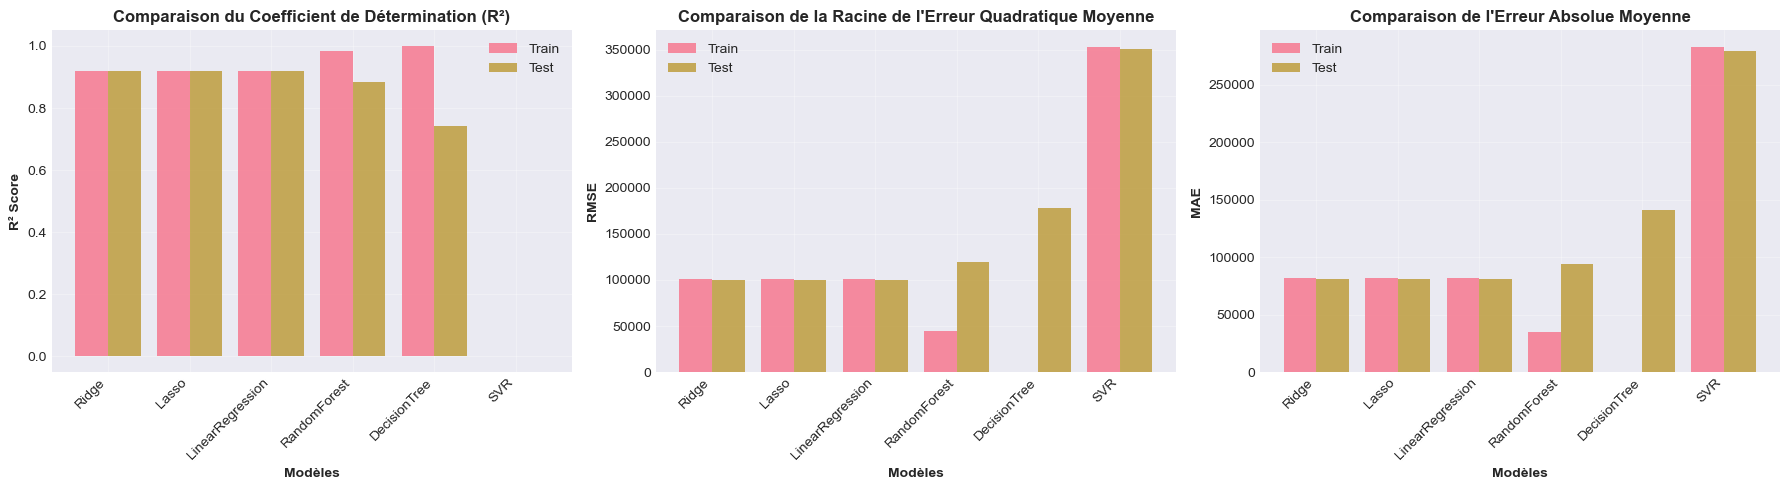

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_pos = np.arange(len(comparaison))
axes[0].bar(x_pos - 0.2, comparaison['R² Train'], 0.4, label='Train', alpha=0.8)
axes[0].bar(x_pos + 0.2, comparaison['R² Test'], 0.4, label='Test', alpha=0.8)
axes[0].set_xlabel('Modèles', fontweight='bold')
axes[0].set_ylabel('R² Score', fontweight='bold')
axes[0].set_title('Comparaison du Coefficient de Détermination (R²)', fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparaison['Modèle'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].bar(x_pos - 0.2, comparaison['RMSE Train'], 0.4, label='Train', alpha=0.8)
axes[1].bar(x_pos + 0.2, comparaison['RMSE Test'], 0.4, label='Test', alpha=0.8)
axes[1].set_xlabel('Modèles', fontweight='bold')
axes[1].set_ylabel('RMSE', fontweight='bold')
axes[1].set_title('Comparaison de la Racine de l\'Erreur Quadratique Moyenne', fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparaison['Modèle'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[2].bar(x_pos - 0.2, comparaison['MAE Train'], 0.4, label='Train', alpha=0.8)
axes[2].bar(x_pos + 0.2, comparaison['MAE Test'], 0.4, label='Test', alpha=0.8)
axes[2].set_xlabel('Modèles', fontweight='bold')
axes[2].set_ylabel('MAE', fontweight='bold')
axes[2].set_title('Comparaison de l\'Erreur Absolue Moyenne', fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(comparaison['Modèle'], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

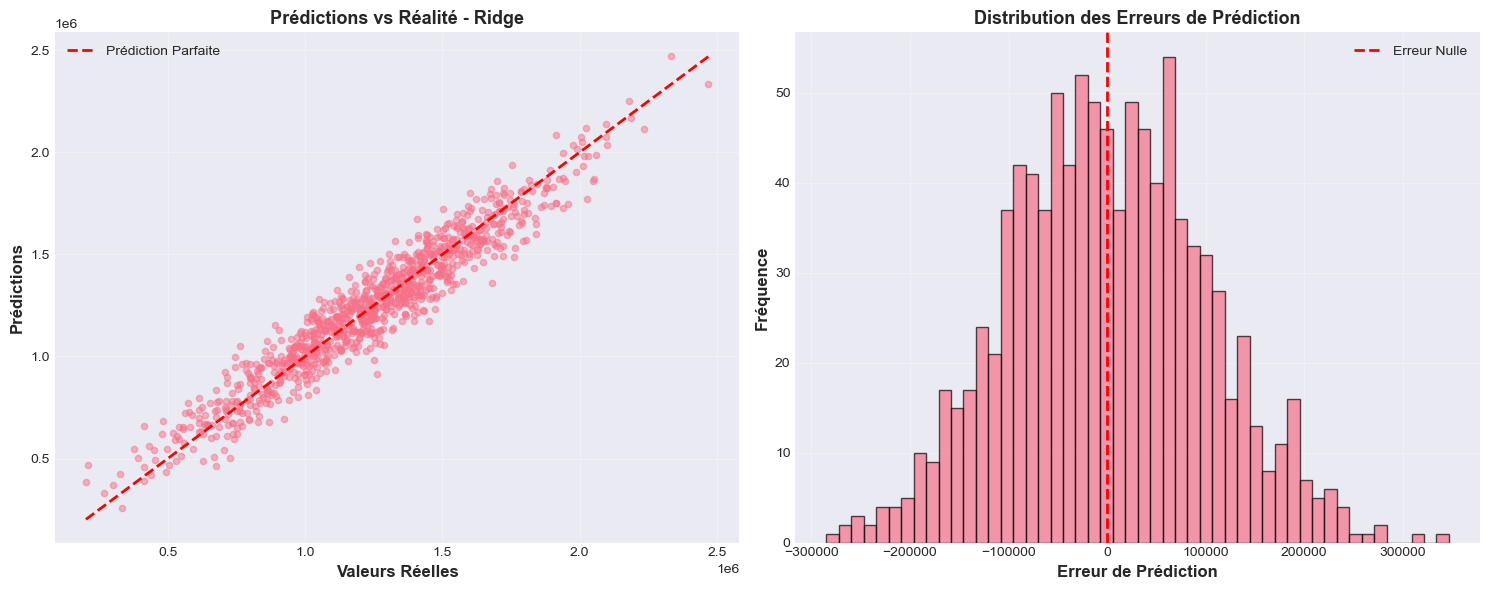

In [68]:
y_pred_meilleur = resultats[meilleur_modele]['predictions']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(y_test, y_pred_meilleur, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Prédiction Parfaite')
axes[0].set_xlabel('Valeurs Réelles', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Prédictions', fontweight='bold', fontsize=12)
axes[0].set_title(f'Prédictions vs Réalité - {meilleur_modele}', fontweight='bold', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

erreurs = y_test - y_pred_meilleur
axes[1].hist(erreurs, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Erreur Nulle')
axes[1].set_xlabel('Erreur de Prédiction', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Fréquence', fontweight='bold', fontsize=12)
axes[1].set_title('Distribution des Erreurs de Prédiction', fontweight='bold', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [69]:
print(f"\nStatistiques sur les erreurs de prédiction :")
print(f"  Erreur moyenne : {erreurs.mean():.4f}")
print(f"  Écart-type des erreurs : {erreurs.std():.4f}")
print(f"  Erreur minimale : {erreurs.min():.4f}")
print(f"  Erreur maximale : {erreurs.max():.4f}")


Statistiques sur les erreurs de prédiction :
  Erreur moyenne : 353.4782
  Écart-type des erreurs : 100493.6676
  Erreur minimale : -284710.2100
  Erreur maximale : 346774.4281


In [70]:
if hasattr(resultats[meilleur_modele]['modele'], 'feature_importances_'):
    importances = resultats[meilleur_modele]['modele'].feature_importances_
    indices = np.argsort(importances)[::-1]
    
    importance_df = pd.DataFrame({
        'Feature': X.columns[indices],
        'Importance': importances[indices]
    })
    
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(importances)), importances[indices], alpha=0.8)
    plt.xticks(range(len(importances)), X.columns[indices], rotation=45, ha='right')
    plt.xlabel('Caractéristiques', fontweight='bold', fontsize=12)
    plt.ylabel('Importance Relative', fontweight='bold', fontsize=12)
    plt.title(f'Importance des Caractéristiques - {meilleur_modele}', 
              fontweight='bold', fontsize=13)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    print("\nClassement des caractéristiques par importance :")
    print(importance_df.to_string(index=False))
else:
    print(f"\nLe modèle {meilleur_modele} ne fournit pas d'importance des caractéristiques.")


Le modèle Ridge ne fournit pas d'importance des caractéristiques.


In [80]:
features = list(X.columns)
nouvelle_maison = pd.DataFrame([{col: X[col].median() for col in X.columns}])

updates = {
    "Avg. Area Income": 65000,
    "Avg. Area House Age": 10,
    "Avg. Area Number of Rooms": 6,
    "Avg. Area Number of Bedrooms": 3,
    "Area Population": 30000                   
}

for col, val in updates.items():
    if col in nouvelle_maison.columns:
        nouvelle_maison[col] = val

if ("Avg. Area Number of Bedrooms" in nouvelle_maison.columns) and ("Avg. Area Number of Rooms" in nouvelle_maison.columns):

    if "RoomsPerBedroom" in X.columns:
        nouvelle_maison["RoomsPerBedroom"] = (
            nouvelle_maison["Avg. Area Number of Rooms"] / nouvelle_maison["Avg. Area Number of Bedrooms"]
        )

if ("Avg. Area Income" in nouvelle_maison.columns) and ("Area Population" in nouvelle_maison.columns):
    if "IncomePerPopProxy" in X.columns:
        nouvelle_maison["IncomePerPopProxy"] = (
            nouvelle_maison["Avg. Area Income"] / nouvelle_maison["Area Population"]
        )

nouvelle_maison = nouvelle_maison[X.columns]

print("\nCaractéristiques de la nouvelle instance (USA_Housing) :")
print("="*60)
for col in nouvelle_maison.columns:
    print(f"{col:30} : {float(nouvelle_maison[col].values[0]):12.4f}")
print("="*60)

best_model = resultats[meilleur_modele]["modele"]

if hasattr(best_model, "named_steps"):
    prediction = best_model.predict(nouvelle_maison)
else:
    nouvelle_maison_scaled = scaler.transform(nouvelle_maison)
    prediction = best_model.predict(nouvelle_maison_scaled)

print(f"\n{'='*60}")
print("PRÉDICTION DU PRIX (USA_Housing)")
print(f"{'='*60}")
print(f"Modèle utilisé : {meilleur_modele}")
print(f"Prix prédit : ${prediction[0]:,.2f}") 
print(f"{'='*60}")


print(f"\nComparaison des prédictions selon différents modèles :")
print(f"{'='*60}")
for nom_modele, obj in resultats.items():
    m = obj["modele"]
    if hasattr(m, "named_steps"):
        pred = m.predict(nouvelle_maison)
    else:
        pred = m.predict(scaler.transform(nouvelle_maison))
    print(f"{nom_modele:30} : ${pred[0]:12,.2f}")
print(f"{'='*60}")


Caractéristiques de la nouvelle instance (USA_Housing) :
Avg. Area Income               :   65000.0000
Avg. Area House Age            :      18.0000
Avg. Area Number of Rooms      :       6.0000
Avg. Area Number of Bedrooms   :       3.0000
Area Population                :   30000.0000

PRÉDICTION DU PRIX (USA_Housing)
Modèle utilisé : Ridge
Prix prédit : $2,919,047.40

Comparaison des prédictions selon différents modèles :
LinearRegression               : $2,919,491.74
Ridge                          : $2,919,047.40
Lasso                          : $2,919,491.64
SVR                            : $1,226,353.09
DecisionTree                   : $  456,019.17
RandomForest                   : $  688,300.12
